# 6. Workflow Routing Insights

Backtracks the trained RL routing agent to extract actionable process improvement recommendations.

## What this notebook does

1. **Runs the trained RL agent** for N episodes and records every routing decision
2. **Compares against a random baseline** to identify which routing choices the agent learned
3. **Identifies preferred routes** — transitions the agent takes much more often than random
4. **Identifies avoided routes** — transitions the agent learned to avoid (especially bad terminals)
5. **Generates recommendations** — translates routing patterns into actionable process rules
6. **Visualises the routing graph** — shows the agent's preferred process flow

## 6.0 Install Dependencies

In [1]:
%matplotlib inline
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'joblib', 'sb3-contrib',
])


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /mnt/hdd/Code/Git/bwa/.venv/bin/python -m pip install --upgrade pip


0

## 6.1 Setup

In [2]:
import sys, json
from pathlib import Path

_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / 'src' / 'data_ingestion.py').exists():
        _repo_root = _p
        _src = str(_p / 'src')
        if _src not in sys.path: sys.path.insert(0, _src)
        break

# Change this to analyse a different dataset
DATASET = "BPIC2012"
OUTPUT_DIR = _repo_root / 'output' / DATASET

# N_EPISODES scaled by dataset size to avoid OOM on large datasets.
# Read activity count from the twin's terminal_classification.json (no joblib needed).
_tc_path = OUTPUT_DIR / 'terminal_classification.json'
_n_acts_hint = len(json.load(open(_tc_path))['activities']) if _tc_path.exists() else 30
N_EPISODES = 300 if _n_acts_hint > 100 else 500
print(f'Dataset:    {DATASET}')
print(f'Output dir: {OUTPUT_DIR}')
print(f'N_EPISODES = {N_EPISODES}  (dataset has {_n_acts_hint} activities)')

Dataset:    BPIC2012
Output dir: /mnt/hdd/Code/Git/bwa/output/BPIC2012
N_EPISODES = 500  (dataset has 24 activities)


## 6.2 Load Model and Environment

In [3]:
import joblib
import gymnasium as gym
from sb3_contrib import MaskablePPO
from env_factory import build_process_env
from kpi_actions import MANAGEMENT_ACTIONS, N_MANAGEMENT_ACTIONS

# Same factory as notebooks 04 and 05, so the rewards recorded against each
# routing decision below are the ones the agent was actually trained on. This
# cell used to build ProcessEnv by hand without the reward weights, which made
# every per-step reward printed here incomparable with the training curves.
env, env_meta = build_process_env(OUTPUT_DIR)
twin     = env.twin
embedder = env.embed_model

model_path = OUTPUT_DIR / 'rl_model' / 'best_model.zip'
model = MaskablePPO.load(model_path, env=env)

print(f'Activities:     {env_meta["n_activities"]}')
print(f'Good terminals: {sorted(env._good_terminals)}')
print(f'Bad terminals:  {sorted(env._bad_terminals)}')
print(f'Action space:   {env.action_space}')
print(f'  Routing dim:    {env.action_space.nvec[0]} actions')
print(f'  Management dim: {env.action_space.nvec[1]} actions ({N_MANAGEMENT_ACTIONS} KPI rules)')
print()
print('Reward (identical to training):')
for k, v in env_meta['reward_config'].items():
    print(f'  {k:<16s} = {v}')

Activities:     24
Good terminals: ['A_ACTIVATED', 'A_APPROVED', 'A_REGISTERED', 'O_ACCEPTED']
Bad terminals:  ['A_CANCELLED', 'A_DECLINED', 'O_DECLINED']
Action space:   MultiDiscrete([14 15])
  Routing dim:    14 actions
  Management dim: 15 actions (15 KPI rules)

Reward (identical to training):
  w_terminal       = 30.0
  w_bad_terminal   = -30.0
  w_length_bonus   = 5.0
  progress_share   = 0.0
  step_share       = 0.02
  w_loop           = 1.0
  time_share       = 0.25
  time_penalty_mode = two_sided
  time_penalty_cap = 6.0
  intervention_cost_share = 1.0
  effect_scale     = 1.0
  w_progress_abs   = None
  w_step_abs       = None


## 6.3 Collect Trajectories

In [4]:
from insights import collect_trajectories, episode_outcome_summary
import numpy as np

print(f'Collecting {N_EPISODES} RL trajectories...')
rl_trajs = collect_trajectories(env, model, n_episodes=N_EPISODES, deterministic=True)

print(f'Collecting {N_EPISODES} random baseline trajectories...')
rng = np.random.default_rng(42)

class RandomPolicy:
    """Random policy compatible with MultiDiscrete([max_succ, n_mgmt]) action space."""
    def predict(self, obs, action_masks=None, deterministic=True):
        import gymnasium as gym
        if isinstance(env.action_space, gym.spaces.MultiDiscrete):
            max_succ = env.action_space.nvec[0]
            routing_mask = action_masks[:max_succ]
            mgmt_mask    = action_masks[max_succ:]
            ri = int(rng.choice(np.where(routing_mask)[0]))
            mi = int(rng.choice(np.where(mgmt_mask)[0]))
            return np.array([ri, mi]), None
        else:
            valid = np.where(action_masks)[0]
            return int(rng.choice(valid)), None

random_trajs = collect_trajectories(env, RandomPolicy(), n_episodes=N_EPISODES)

rl_summary     = episode_outcome_summary(rl_trajs)
random_summary = episode_outcome_summary(random_trajs)

import gc
gc.collect()

print(f'\n{"Metric":<25} {"Random":>10}  {"Our RL":>10}')
print('-' * 48)
for key in ['mean_reward', 'std_reward', 'terminal_rate', 'bad_terminal_rate', 'mean_length']:
    print(f'{key:<25} {random_summary[key]:>10.3f}  {rl_summary[key]:>10.3f}')



Metric                        Random      Our RL
------------------------------------------------
mean_reward                    0.799      16.049
std_reward                    15.190      13.457
terminal_rate                  1.000       1.000
bad_terminal_rate              0.826       0.818
mean_length                   19.200      11.900


## 6.4 Routing Preference Analysis

For each `(from_activity, to_activity)` pair, compare how often the RL agent
chose it vs the random baseline.
- `preference_ratio > 1` means the agent prefers this route
- `preference_ratio < 1` means it avoids it

In [5]:
from insights import routing_preference_table
import pandas as pd

# Load real event log for impossible-transition cross-referencing
_log_path = OUTPUT_DIR / f'events_{DATASET}_train.parquet'
real_log_df = pd.read_parquet(_log_path) if _log_path.exists() else None
if real_log_df is not None:
    print(f'Loaded real log: {len(real_log_df)} events for transition validation')
else:
    print('Real log not found — transition_type will be "unknown"')

# smoothing_alpha=0.5 (Jeffreys prior) prevents 0/0 and caps extreme ratios
pref_df = routing_preference_table(rl_trajs, random_trajs,
                                   real_log_df=real_log_df, smoothing_alpha=0.5)

# Show transition type breakdown
if 'transition_type' in pref_df.columns:
    print()
    print('Transition type breakdown:')
    print(pref_df['transition_type'].value_counts().to_string())
    print()

print('Top 15 PREFERRED routes (RL >> Random):')
top_pref = pref_df[pref_df['rl_count'] >= 3].head(15)
print(top_pref[['from_activity','to_activity','rl_pct','random_pct',
                'log2_ratio','transition_type','avg_reward_rl']].to_string(index=False))

print()
print('Top 10 AVOIDED routes — learned avoidances only (not impossible transitions):')
learned_avoid = pref_df[
    (pref_df['transition_type'] == 'learned_avoid') &
    (pref_df['random_count'] >= 3)
].tail(10)
print(learned_avoid[['from_activity','to_activity','rl_pct','random_pct',
                      'log2_ratio','transition_type','avg_reward_rl']].to_string(index=False))

print()
print('Impossible transitions (in twin but not in real log):')
impossible = pref_df[pref_df['transition_type'] == 'impossible']
print(f'  {len(impossible)} transitions flagged as impossible (twin artefacts)')
if not impossible.empty:
    print(impossible[['from_activity','to_activity','rl_count','random_count']].head(10).to_string(index=False))


Loaded real log: 262200 events for transition validation



Transition type breakdown:
transition_type
neutral           27
learned_prefer    21
learned_avoid     15

Top 15 PREFERRED routes (RL >> Random):
         from_activity            to_activity  rl_pct  random_pct  log2_ratio transition_type  avg_reward_rl
W_Completeren aanvraag W_Completeren aanvraag    67.3        12.8       2.388  learned_prefer         -0.055
    W_Afhandelen leads     W_Afhandelen leads   100.0        26.0       1.937  learned_prefer         -0.055
   W_Beoordelen fraude     W_Afhandelen leads   100.0        26.6       1.906  learned_prefer         -0.055
     A_PARTLYSUBMITTED          A_PREACCEPTED   100.0        31.8       1.650  learned_prefer         -0.055
W_Completeren aanvraag    W_Beoordelen fraude    32.7        14.4       1.175  learned_prefer         -0.055
           A_SUBMITTED      A_PARTLYSUBMITTED   100.0       100.0       0.000         neutral         -0.055
         A_PREACCEPTED W_Completeren aanvraag   100.0       100.0       0.000         neu

## 6.5 Recommendations

In [6]:
from insights import generate_recommendations, print_insights_report, management_action_summary

rec_df  = generate_recommendations(pref_df, env, top_n=12)
mgmt_df = management_action_summary(rl_trajs, random_trajs)

print_insights_report(rec_df, rl_summary, random_summary, DATASET, mgmt_df=mgmt_df)

rec_df.to_csv(OUTPUT_DIR / 'routing_recommendations.csv', index=False)
pref_df.to_csv(OUTPUT_DIR / 'routing_preferences.csv', index=False)
mgmt_df.to_csv(OUTPUT_DIR / 'management_action_usage.csv', index=False)
print(f'Saved to {OUTPUT_DIR}')


  WORKFLOW ROUTING INSIGHTS — BPIC2012
  RL Backtracking Analysis (500 episodes)

  OUTCOME COMPARISON
  Metric                        Random      Our RL      Change
  ------------------------------------------------------------
  Mean reward                    0.799      16.049  + +15.250
  Terminal rate                  1.000       1.000  - +0.000
  Bad terminal rate              0.826       0.818  + -0.008
  Mean length                   19.200      11.900  + -7.300

  MANAGEMENT ACTION USAGE (RL vs Random, top 8 by RL rate)
  Action                                      RL rate  Rnd rate   Ratio
  ----------------------------------------------------------------------
  assign_to_primary_team                        90.1%     31.0%     2.9x
  enable_cross_trained_pool                      8.7%      4.3%     2.0x
  reroute_from_overloaded_employee               1.1%      4.6%     0.2x

  TOP ROUTING RECOMMENDATIONS
  #    Type         From                           To                  

## 6.5b Management Action Usage

Compares which KPI-based management actions the RL policy uses vs random.
Actions the RL uses significantly more than random indicate learned intervention patterns.

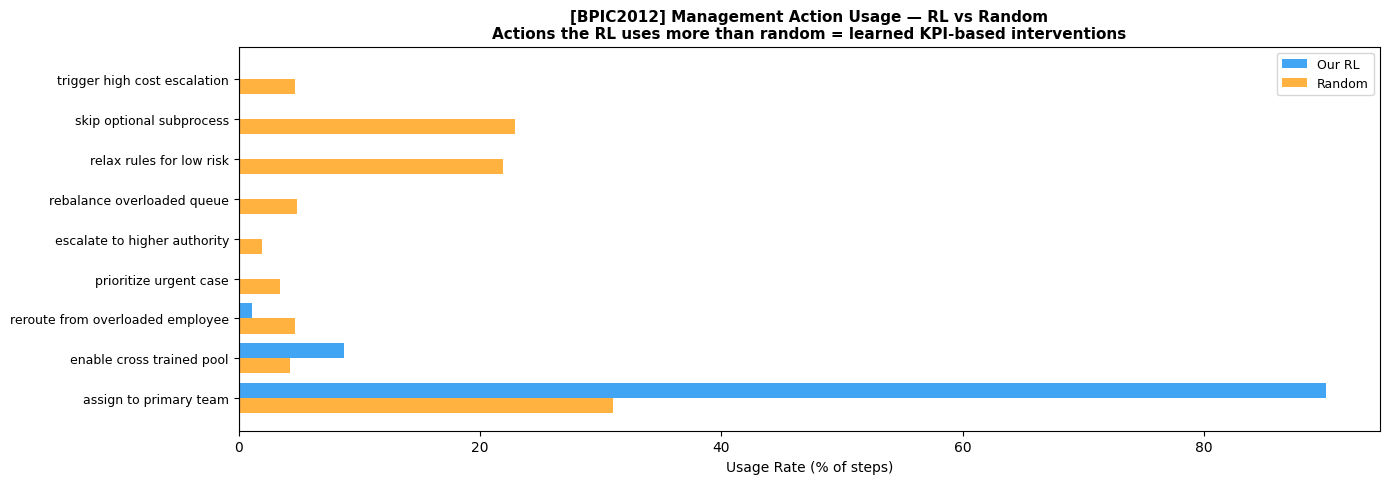

Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/management_action_usage.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

if not mgmt_df.empty:
    # Only show actions with meaningful usage (>0.5% of steps by either policy)
    sig_mgmt = mgmt_df[(mgmt_df['rl_rate'] > 0.005) | (mgmt_df['random_rate'] > 0.005)].copy()

    if not sig_mgmt.empty:
        fig, ax = plt.subplots(figsize=(14, max(4, len(sig_mgmt) * 0.55)))
        x = np.arange(len(sig_mgmt))
        bw = 0.38
        ax.barh(x + bw/2, sig_mgmt['rl_rate'] * 100,   bw, label='Our RL',  color='#2196F3', alpha=0.85)
        ax.barh(x - bw/2, sig_mgmt['random_rate'] * 100, bw, label='Random', color='#FF9800', alpha=0.75)
        ax.set_yticks(x)
        ax.set_yticklabels(sig_mgmt['mgmt_action'].str.replace('_', ' '), fontsize=9)
        ax.set_xlabel('Usage Rate (% of steps)', fontsize=10)
        ax.set_title(f'[{DATASET}] Management Action Usage — RL vs Random\n'
                     'Actions the RL uses more than random = learned KPI-based interventions',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.axvline(0, color='#555', lw=0.8)
        plt.tight_layout()
        fig.savefig(OUTPUT_DIR / 'management_action_usage.png', dpi=150, bbox_inches='tight')
        display(fig)
        plt.close(fig)
        print(f'Saved to {OUTPUT_DIR / "management_action_usage.png"}')
    else:
        print('No management actions with >0.5% usage rate.')
else:
    print('No management action data available.')


## 6.5c Decision Rules (If-Then Policy Export)

Converts the RL policy into human-readable if-then routing rules for business stakeholders.
Each rule describes the KPI context (delay level, rework, case age, volume) under which
the agent makes a specific routing decision.

Rules are sorted by `support × avg_reward` — high-frequency, high-value decisions first.

In [8]:
from insights import extract_decision_rules, print_decision_rules
import pandas as pd

rules_df = extract_decision_rules(rl_trajs, env, min_support=5, max_rules=25)
print_decision_rules(rules_df, DATASET)

# Save for business stakeholders
rules_df.to_csv(OUTPUT_DIR / 'routing_decision_rules.csv', index=False)

# Also print as a clean table
if not rules_df.empty:
    print()
    print('Decision rules table (for export):')
    display_cols = ['rank', 'from_activity', 'to_activity', 'support',
                    'avg_reward', 'condition_delay', 'condition_rework',
                    'condition_case_age', 'condition_volume']
    pd.set_option('display.max_colwidth', 40)
    print(rules_df[display_cols].to_string(index=False))
    print(f'\nSaved to {OUTPUT_DIR / "routing_decision_rules.csv"}')

# ── Free trajectory memory — this is the last cell that needs rl_trajs/random_trajs ──
# KPI fields per step are the biggest consumers; strip them now.
import gc
for _t in rl_trajs + random_trajs:
    for _s in _t.get('steps', []):
        _s.pop('kpi_delay',    None)
        _s.pop('kpi_rework',   None)
        _s.pop('kpi_loop_rate',None)
        _s.pop('kpi_case_age', None)
        _s.pop('kpi_term_prox',None)
        _s.pop('kpi_volume',   None)
gc.collect()
print('Trajectory KPI fields freed.')


  EXTRACTED ROUTING RULES — BPIC2012
  (7 rules, sorted by support × reward)

  Rule  1
  IF at 'A_SUBMITTED' AND low delay AND low rework AND early in case AND normal volume THEN route to 'A_PARTLYSUBMITTED'
  Support: 500 steps  |  Avg reward: -0.055

  Rule  2
  IF at 'A_PARTLYSUBMITTED' AND low delay AND low rework AND early in case AND normal volume THEN route to 'A_PREACCEPTED'
  Support: 500 steps  |  Avg reward: -0.055

  Rule  3
  IF at 'A_PREACCEPTED' AND low delay AND low rework AND early in case AND normal volume THEN route to 'W_Completeren aanvraag'
  Support: 500 steps  |  Avg reward: -0.055

  Rule  4
  IF at 'W_Completeren aanvraag' AND low delay AND low rework AND early in case AND normal volume THEN route to 'W_Completeren aanvraag'
  Support: 916 steps  |  Avg reward: -0.055

  Rule  5
  IF at 'W_Completeren aanvraag' AND low delay AND low rework AND early in case AND normal volume THEN route to 'W_Beoordelen fraude'
  Support: 445 steps  |  Avg reward: -0.055

  Ru

## 6.6 Routing Preference Heatmap

Blue = agent prefers this route over random.  
Red = agent avoids this route vs random.  
White = same as random.  
Red column borders mark bad terminal activities.

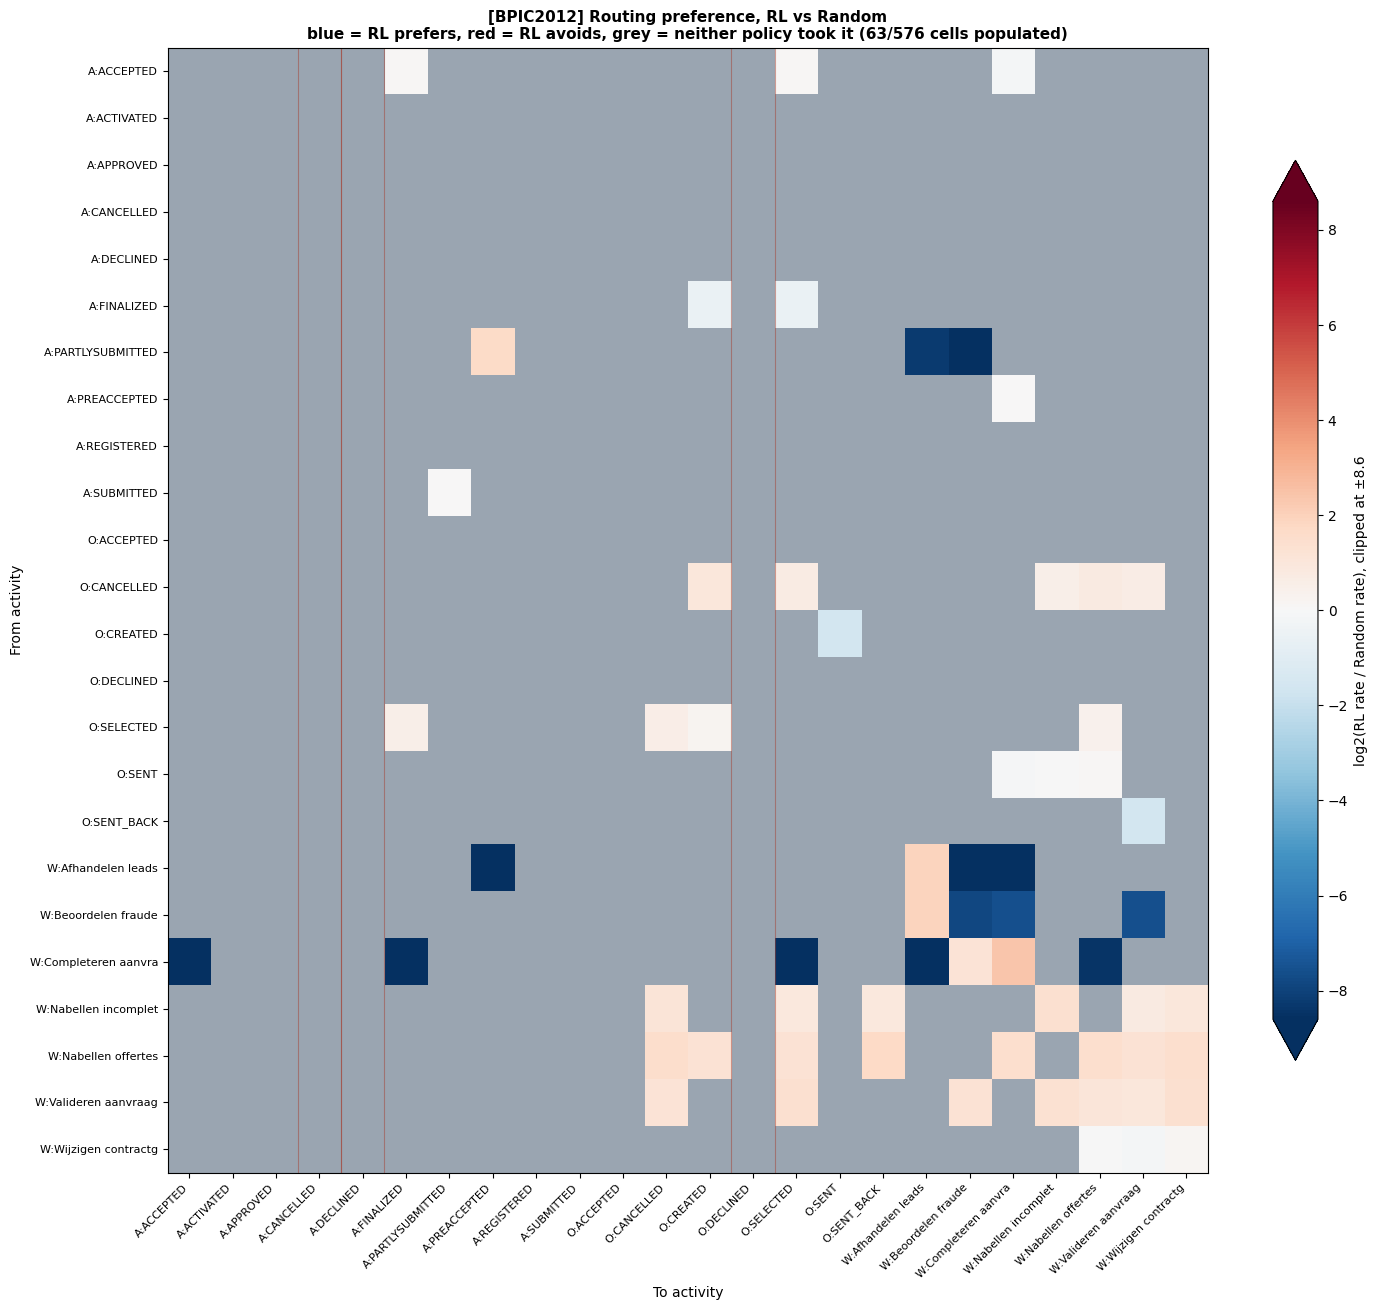

Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/routing_preference_heatmap.png


143

In [9]:
import figures

# Fixes a real bug. The old code computed
#     ratio_mat[i, j] = np.log2(max(row['log2_ratio'], 0.01))
# taking log2 of a value that is already a log2, and clamping every negative
# entry - every route the agent avoids - to a single number. On BPIC2012 that
# collapsed 47 of 63 populated cells (74.6%) to one shade, so the whole "RL
# avoids" half of the legend carried no information while the axis label
# described a quantity that was not being plotted.
#
# Cells neither policy ever visits are now masked grey instead of drawn as 0:
# on BPIC2012 that is 89% of the matrix, and 0 previously read as "both
# policies took this equally often".
_fig = figures.routing_heatmap(
    pref_df,
    activities=sorted(twin.activities),
    out_path=OUTPUT_DIR / 'routing_preference_heatmap.png',
    dataset=DATASET,
    bad_terminals=env._bad_terminals,
)
if _fig is None:
    print(f'Skipped heatmap - {len(twin.activities)} activities is too many to render.')
    print('See section 6.8 (Top Routing Divergences) instead.')
else:
    display(_fig)
    print(f'Saved to {OUTPUT_DIR / "routing_preference_heatmap.png"}')

import gc; gc.collect()


## 6.7 Episode Outcome Distribution

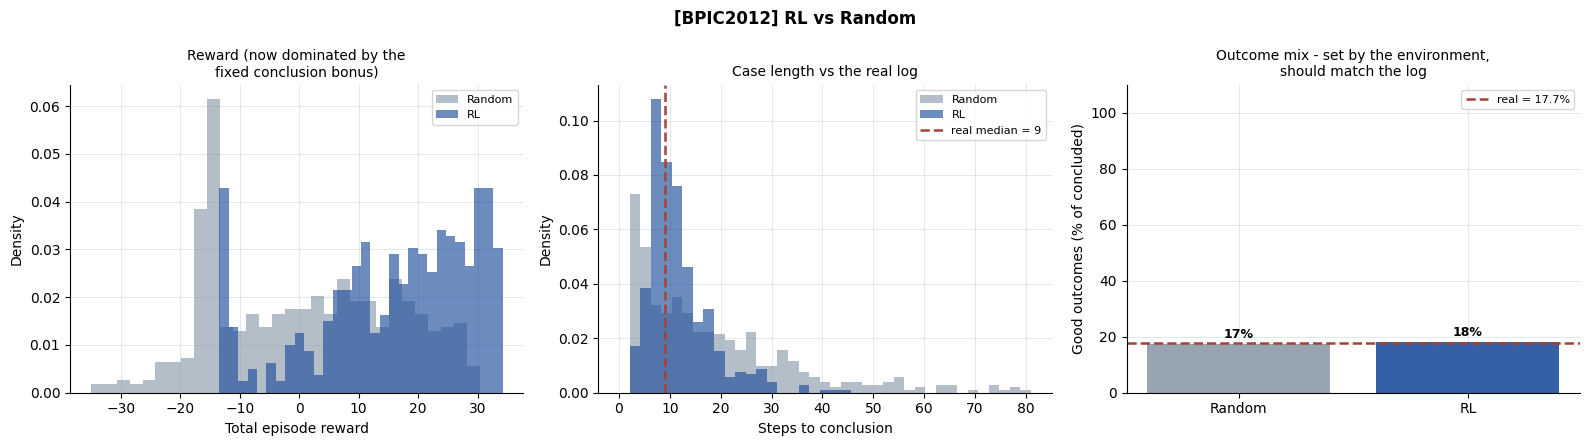

Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/episode_outcomes.png


In [10]:
import figures
import matplotlib.pyplot as plt
import numpy as np
import json

_tc = json.load(open(OUTPUT_DIR / 'terminal_classification.json'))
_real_median = _tc['steps_to_outcome']['p50']

# The third panel used to be "Final Activity Distribution", comparing RL
# against Random. The final activity is now drawn by the environment, so the
# two are identical by construction and that panel could only ever show noise.
# Replaced with steps-to-conclusion against the real log, which is where the
# policies genuinely differ.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(f'[{DATASET}] RL vs Random', fontsize=12, fontweight='bold')

rl_rewards  = [t['total_reward'] for t in rl_trajs]
rnd_rewards = [t['total_reward'] for t in random_trajs]
axes[0].hist(rnd_rewards, bins=30, alpha=0.65, color=figures.C['baseline'],
             label='Random', density=True)
axes[0].hist(rl_rewards,  bins=30, alpha=0.65, color=figures.C['rl'],
             label='RL', density=True)
axes[0].set_xlabel('Total episode reward'); axes[0].set_ylabel('Density')
axes[0].set_title('Reward (now dominated by the\nfixed conclusion bonus)', fontsize=10)
axes[0].legend(fontsize=8)

rl_lens  = [t['n_steps'] for t in rl_trajs]
rnd_lens = [t['n_steps'] for t in random_trajs]
_bins = np.linspace(0, max(np.percentile(rnd_lens, 99), np.percentile(rl_lens, 99)), 40)
axes[1].hist(rnd_lens, bins=_bins, alpha=0.65, color=figures.C['baseline'],
             label='Random', density=True)
axes[1].hist(rl_lens,  bins=_bins, alpha=0.65, color=figures.C['rl'],
             label='RL', density=True)
axes[1].axvline(_real_median, color=figures.C['real'], ls='--', lw=1.8,
                label=f'real median = {_real_median:.0f}')
axes[1].set_xlabel('Steps to conclusion'); axes[1].set_ylabel('Density')
axes[1].set_title('Case length vs the real log', fontsize=10)
axes[1].legend(fontsize=8)

_good = set(_tc['good_terminals'])
rates = []
for trajs in (random_trajs, rl_trajs):
    done = [t for t in trajs if t['terminated']]
    rates.append(100 * sum(t['final_activity'] in _good for t in done) / max(len(done), 1))
axes[2].bar(['Random', 'RL'], rates, color=[figures.C['baseline'], figures.C['rl']], alpha=0.9)
axes[2].axhline(_tc['outcome_base_rates']['p_good'] * 100, color=figures.C['real'],
                ls='--', lw=1.8, label=f"real = {_tc['outcome_base_rates']['p_good']:.1%}")
for i, v in enumerate(rates):
    axes[2].text(i, v + 2, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)
axes[2].set_ylim(0, 110); axes[2].set_ylabel('Good outcomes (% of concluded)')
axes[2].set_title('Outcome mix - set by the environment,\nshould match the log', fontsize=10)
axes[2].legend(fontsize=8)

for ax in axes:
    figures._style(ax)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'episode_outcomes.png', dpi=150, bbox_inches='tight')
display(fig); plt.close(fig)
print(f'Saved to {OUTPUT_DIR / "episode_outcomes.png"}')


## 6.8 Top Routing Divergences

Horizontal bar chart of the routes where the RL agent diverges most from random.  
Value labels show the multiplier (e.g. 3.2x = RL is 3.2x more/less likely than random).

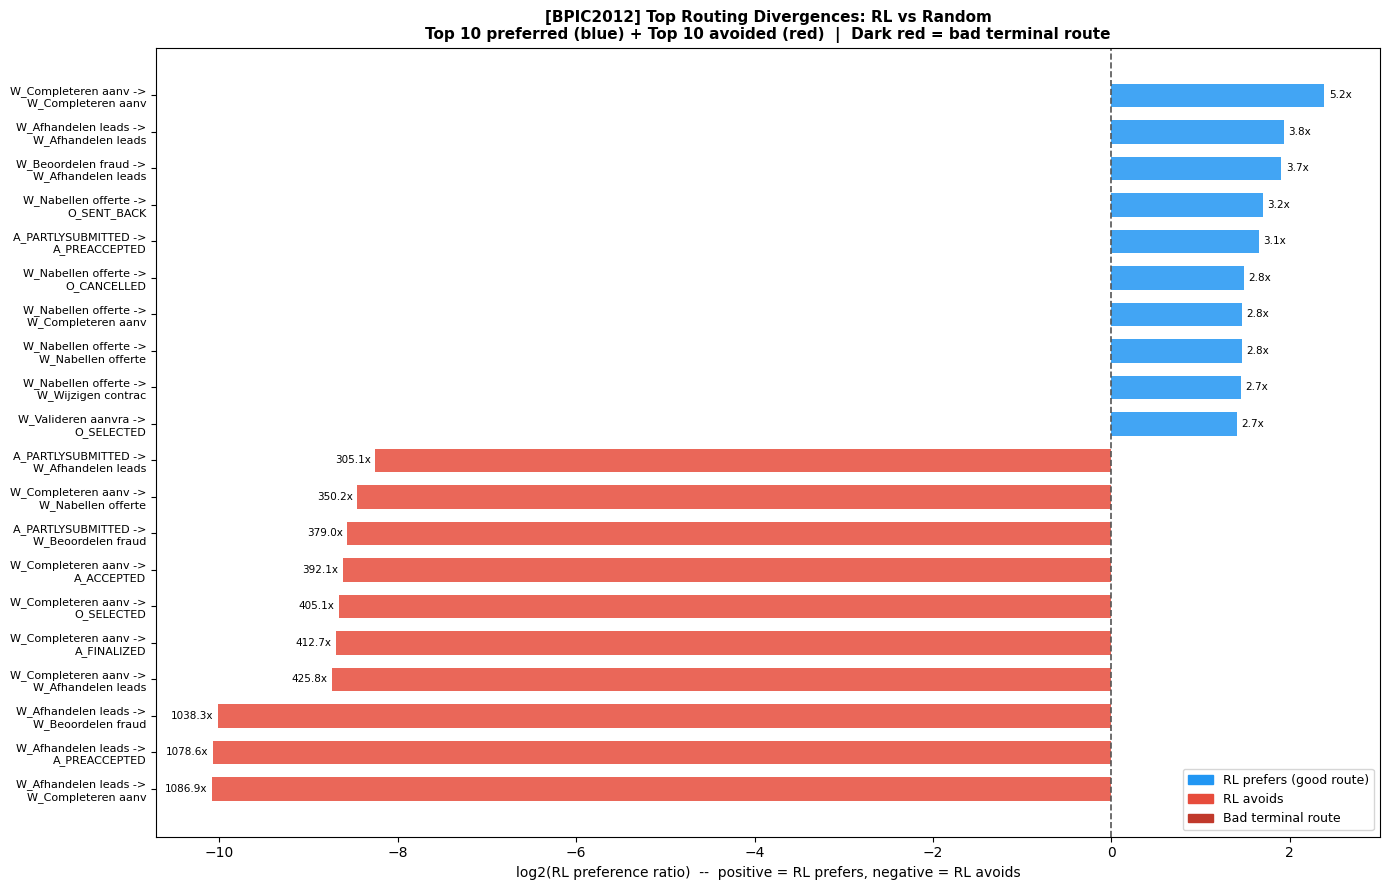

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

sig = pref_df[(pref_df['rl_count'] + pref_df['random_count']) >= 5].copy()
sig['log_ratio'] = sig['log2_ratio']
sig['route'] = sig['from_activity'].str[:18] + ' ->\n' + sig['to_activity'].str[:18]

# Balanced selection: top 10 most preferred (positive) + top 10 most avoided (negative)
# Sorting by absolute value alone hides all blue bars when avoidances dominate.
top_prefers = sig[sig['log_ratio'] > 0].nlargest(10, 'log_ratio')
top_avoids  = sig[sig['log_ratio'] < 0].nsmallest(10, 'log_ratio')
sig = pd.concat([top_prefers, top_avoids]).sort_values('log_ratio', ascending=True)

colors = ['#c0392b' if row['to_activity'] in env._bad_terminals
          else ('#2196F3' if row['log_ratio'] > 0 else '#e74c3c')
          for _, row in sig.iterrows()]

fig, ax = plt.subplots(figsize=(14, max(8, len(sig) * 0.45)))
bars = ax.barh(range(len(sig)), sig['log_ratio'], color=colors, alpha=0.85, height=0.65)
ax.axvline(0, color='#555', lw=1.2, ls='--')
ax.set_yticks(range(len(sig)))
ax.set_yticklabels(sig['route'], fontsize=8)
ax.set_xlabel('log2(RL preference ratio)  --  positive = RL prefers, negative = RL avoids',
              fontsize=10)
ax.set_title(f'[{DATASET}] Top Routing Divergences: RL vs Random\n'
             f'Top {len(top_prefers)} preferred (blue) + Top {len(top_avoids)} avoided (red)  |  Dark red = bad terminal route',
             fontsize=11, fontweight='bold')

for bar, (_, row) in zip(bars, sig.iterrows()):
    v = row['log_ratio']
    xpos = v + 0.05 if v >= 0 else v - 0.05
    ha = 'left' if v >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{2**abs(v):.1f}x', va='center', ha=ha, fontsize=7.5)

patches = [
    mpatches.Patch(color='#2196F3', label='RL prefers (good route)'),
    mpatches.Patch(color='#e74c3c', label='RL avoids'),
    mpatches.Patch(color='#c0392b', label='Bad terminal route'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'routing_divergences.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

## 6.9 Recommendations Summary Table

In [12]:
import pandas as pd

if not rec_df.empty:
    pd.set_option('display.max_colwidth', 120)
    pd.set_option('display.max_rows', 20)
    display_cols = ['rank', 'type', 'from_activity', 'to_activity',
                    'rl_pct', 'random_pct', 'ratio', 'recommendation']
    print(f'{len(rec_df)} recommendations for {DATASET}:')
    print(rec_df[display_cols].to_string(index=False))
else:
    print('No significant routing divergences found.')
    print('Try increasing N_EPISODES or retraining with more steps.')

6 recommendations for BPIC2012:
 rank  type          from_activity            to_activity  rl_pct  random_pct  ratio                                                                                                                                                         recommendation
    1 AVOID W_Completeren aanvraag             O_SELECTED     0.0        14.8  0.002         The agent avoids 'W_Completeren aanvraag' to 'O_SELECTED'. This path may lead to loops or inefficiency. Consider adding a routing constraint to discourage it.
    2 AVOID W_Completeren aanvraag            A_FINALIZED     0.0        15.1  0.002        The agent avoids 'W_Completeren aanvraag' to 'A_FINALIZED'. This path may lead to loops or inefficiency. Consider adding a routing constraint to discourage it.
    3 AVOID W_Completeren aanvraag     W_Afhandelen leads     0.0        15.6  0.002 The agent avoids 'W_Completeren aanvraag' to 'W_Afhandelen leads'. This path may lead to loops or inefficiency. Consider adding